In [299]:
import numpy as np
import pandas as pd

In [300]:
ACTIVATION_FN={"linear":lambda Z:Z, 
               "sigmoid":lambda Z:1/(1+np.exp(-Z)), 
               "relu":lambda Z:np.maximum(Z,0), 
               "tanh": lambda Z:(np.exp(Z)-np.exp(-Z))/(np.exp(Z)+np.exp(-Z))}
DERIVATIVE={"linear":lambda Z:np.ones_like(Z), 
            "sigmoid":lambda Z:np.exp(-Z)/(1+np.exp(-Z))**2, 
            "relu":lambda Z:(Z>0).astype(float),
            "tanh": lambda Z:1-np.tanh(Z)**2}

def sigmoid(Z):
    exp_Z=np.exp(Z-np.max(Z,axis=1,keepdims=True))
    return exp_Z/np.sum(exp_Z,axis=1,keepdims=True)

def sigmoid_derivative(Z):
    s=sigmoid(Z)
    return s*(1-s)

In [301]:
class MSE:
    def __call__(self,y_true,y_pred):
        return np.mean((y_pred-y_true)**2)
    
    def gradient(self,y_true,y_pred):
        m=y_true.shape[0]
        return 2*(y_pred-y_true)/m

class BinaryCrossEntropy:
    def __call__(self,y_true,y_pred):
        eps=1e-15
        y_pred=np.clip(y_pred,eps,1-eps)
        return -np.mean(y_pred*np.log(y_pred)+(1-y_pred)*np.log(1-y_pred))

    def gradient(self,y_true,y_pred):
        eps=1e-15
        m=y_true.shape[0]
        y_pred=np.clip(y_pred,eps,1-eps)
        return -((y_true/y_pred)+((y_true-1)/(1-y_pred)))

class CategoricalCrossEntropy:
    def __call__(self,y_true,y_pred):
        m=y_true.shape[0]
        eps=1e-15
        y_pred=np.clip(y_pred,eps,1-eps)       
        return -np.sum(y_true*np.log(y_pred))/m

    def gradient(self,y_true,y_pred):
        m=y_true.shape[0]
        eps=1e-15
        y_pred=np.clip(y_pred,eps,1-eps)
        return (-y_true/y_pred)/m

In [302]:
import numpy as np

class GD:
    def __init__(self,lr=0.01):
        self.lr=lr
    def update(self,W,dW,key):
        return W-self.lr*dW

class Momentum:
    def __init__(self,lr=0.01,beta=0.9):
        self.lr=lr
        self.beta=beta
        self.v={}
    def update(self,W,dW,key):
        if key not in self.v:self.v[key]=np.zeros_like(W)

        self.v[key]=self.v[key]+self.lr*dW
        W=W-self.lr*self.v[key]
        return W

class Adam:
    def __init__(self,lr=0.01,beta1=0.9,beta2=0.99):
        self.lr=lr
        self.beta1=beta1
        self.beta2=beta2
        self.v={}
        self.m={}
        self.t={}
    def update(self,W,dW,key):
        if key not in self.v:self.v[key]=np.zeros_like(W)
        if key not in self.m:self.m[key]=np.zeros_like(W)
        if key not in self.t:self.t[key]=0

        self.t[key]+=1

        self.v[key]=self.beta2*self.v[key]+(1-self.beta2)*(dW**2)
        self.m[key]=self.beta1*self.m[key]+(1-self.beta1)*dW

        m_modif=self.m[key]/(1-np.power(self.beta1,self.t[key]))
        v_modif=self.v[key]/(1-np.power(self.beta2,self.t[key]))
        W=W-((self.lr/np.sqrt(v_modif+1e-10))*m_modif)
        return W

In [303]:
class NeuralNetworks:
    def __init__(self,dimensions:list[int],activation_fn_list:list[str],loss_fn="mse"):
        self.dimensions=dimensions
        self.activation_fn_list=activation_fn_list
        self.layers=[]
        self.X_input=None
        self.y_actual=None

        loss_map={"mse":MSE(),"bce":BinaryCrossEntropy(),"cce":CategoricalCrossEntropy()}
        self.loss_fn=loss_map[loss_fn]

    def actual_output(self,y_actual):
        self.y_actual=y_actual

    def take_input(self,X_input):
        self.X_input=X_input
        
    def build_layers(self):
        self.layers=[]
        m,n=self.X_input.shape
        current_dimension=[n]+self.dimensions

        for i in range(1,len(current_dimension)):
            layer=Layer(current_dimension[i],current_dimension[i-1],self.activation_fn_list[i-1])
            self.layers.append(layer)

    def forward_prop(self):
        if not self.layers: self.build_layers()
            
        A_prev=self.X_input
        for layer in self.layers:
            _,A=layer.forward(A_prev)
            A_prev=A
        return A

    def calculate_loss(self,y_pred):
        loss=np.mean((self.y_actual-y_pred)**2)
        return loss

    def train(self,batch_size,optimizer,epochs=100,learning_rate=0.01):
        m=self.X_input.shape[0]
        X_initial=self.X_input
        # creating an empty list to keep track of loss at each epoch
        loss_history=[]
        
        for epoch in range(epochs):

            indices=np.arange(m)
            np.random.shuffle(indices)
            X_shuffled=self.X_input[indices]
            y_shuffled_actual=np.array(self.y_actual)[indices]

            for b in range(0,m,batch_size):
                X_batch=X_shuffled[b:b+batch_size]
                y_batch_actual=y_shuffled_actual[b:b+batch_size]
                current_batch_size=X_batch.shape[0]

                self.X_input=X_batch
                y_batch_pred=self.forward_prop()

                dA=self.loss_fn.gradient(y_batch_actual,y_batch_pred)
                
                for i in range(len(self.layers)-1,-1,-1):
                    curr_layer=self.layers[i]
                    A_prev=self.X_input if i==0 else self.layers[i-1].A
                    
                    # basic four lines of code for each layer for autograd(automatic differentiation) to run gradient descent
                    if i==len(self.layers)-1 and curr_layer.activation_fn_name=="softmax":
                        dZ=(y_batch_pred-y_batch_actual)/current_batch_size
                    else: dZ=dA*curr_layer.derivative_fn(curr_layer.Z)
                    
                    dA_prev=np.dot(dZ,curr_layer.W.T)
                    dW=np.dot(A_prev.T,dZ)
                    db=np.sum(dZ,axis=0,keepdims=True)
                    
                    # updating dA to work for the next previous layer
                    dA=dA_prev

                    # updating the weights and biases
                    curr_layer.W=optimizer.update(curr_layer.W,dW,f"W{i}")
                    curr_layer.b=optimizer.update(curr_layer.b,db,f"b{i}")

            self.X_input=X_initial
            y_pred=self.forward_prop()
            loss=self.calculate_loss(y_pred)
            # print(f"Loss at epoch {epoch}:{loss}")
            loss_history.append(loss)
        return loss_history

In [304]:
class Layer:
    def __init__(self,num_curr,num_prev,activation_fn_name:str):
        self.num_curr=num_curr
        self.num_prev=num_prev
        self.activation_fn_name=activation_fn_name
        self.activation_fn=ACTIVATION_FN[activation_fn_name]
        self.derivative_fn=DERIVATIVE[activation_fn_name]
        self.W,self.b=self.initialize_weights()
        self.Z,self.A=None,None
        
    def initialize_weights(self):
        m,n=self.num_prev,self.num_curr
        weights=np.random.randn(self.num_prev,self.num_curr)
        bias=np.zeros((1,self.num_curr))

        # he-weight(for relu), glorot weight(for sigmoig,tanh) initialization technique
        if self.activation_fn_name=="relu": weights=weights*np.sqrt(2/m)
        else: weights=weights*np.sqrt(1/m)
            
        return weights,bias
        
    # considering dimensions of input of each layer as m*n where m=number of examples, n=dimension of each input, 
    # and dimension of weights as n*k where n=dimension of each input and k=number of neurons

    def forward(self,A_prev):
        self.Z=np.dot(A_prev,self.W)+self.b
        self.A=self.activation_fn(self.Z)
        return self.Z,self.A

In [305]:
np.random.seed(42)

# generating 100 samples with 3 features each for testing
X=np.random.randn(100,3)
y=3*X[:,0:1]**2+2*X[:,1:2]+1.5*X[:,2:3]+5
y+=np.random.normal(0,0.1,size=y.shape)

nn=NeuralNetworks(dimensions=[5,4,1],activation_fn_list=["relu","relu","linear"])
nn.take_input(X)
nn.actual_output(y)
loss_history_GD=nn.train(batch_size=20,optimizer=GD())

In [306]:
np.random.seed(42)

# generating 100 samples with 3 features each for testing
X=np.random.randn(100,3)
y=3*X[:,0:1]**2+2*X[:,1:2]+1.5*X[:,2:3]+5
y+=np.random.normal(0,0.1,size=y.shape)

nn=NeuralNetworks(dimensions=[5,4,1],activation_fn_list=["relu","relu","linear"])
nn.take_input(X)
nn.actual_output(y)
loss_history_M=nn.train(batch_size=20,optimizer=Momentum())

In [307]:
np.random.seed(42)

# generating 100 samples with 3 features each for testing
X=np.random.randn(100,3)
y=3*X[:,0:1]**2+2*X[:,1:2]+1.5*X[:,2:3]+5
y+=np.random.normal(0,0.1,size=y.shape)

nn=NeuralNetworks(dimensions=[5,4,1],activation_fn_list=["relu","relu","linear"])
nn.take_input(X)
nn.actual_output(y)
loss_history_A=nn.train(batch_size=20,optimizer=Adam())

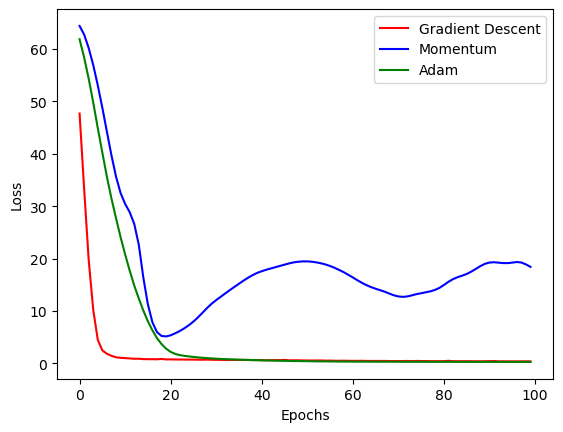

In [308]:
import matplotlib.pyplot as plt

plt.plot(loss_history_GD,color="red",label="Gradient Descent")
plt.plot(loss_history_M,color="blue",label="Momentum")
plt.plot(loss_history_A,color="green",label="Adam")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()